# Adam: A Method for Stochastic Optimization

Replication of Kingma and Ba (2014), *Adam: A Method for Stochastic Optimization*, ICLR.

We implement the Adam update rule from scratch (bias-corrected first and second moment
estimates) and compare it against plain SGD, SGD with momentum, and RMSprop when training
a logistic regression / MLP classifier on MNIST. Reproducing Figure 1 of the paper, Adam
drives the training cost down faster than the baselines.

In [1]:
import torch, torch.nn as nn
import torchvision as tv, torchvision.transforms as T
import matplotlib.pyplot as plt
torch.manual_seed(0)

In [2]:
tf = T.Compose([T.ToTensor(), T.Normalize((0.1307,), (0.3081,))])
train = tv.datasets.MNIST("../data", train=True, download=True, transform=tf)
train_dl = torch.utils.data.DataLoader(train, batch_size=128, shuffle=True)
print("train", len(train))

train 60000


In [3]:
# Adam optimizer implemented directly from Algorithm 1 of the paper.
class Adam:
    def __init__(self, params, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
        self.p = list(params); self.lr, self.b1, self.b2, self.eps = lr, b1, b2, eps
        self.m = [torch.zeros_like(p) for p in self.p]
        self.v = [torch.zeros_like(p) for p in self.p]
        self.t = 0
    def zero_grad(self):
        for p in self.p:
            if p.grad is not None: p.grad.detach_(); p.grad.zero_()
    @torch.no_grad()
    def step(self):
        self.t += 1
        for i, p in enumerate(self.p):
            g = p.grad
            self.m[i] = self.b1*self.m[i] + (1-self.b1)*g          # 1st moment
            self.v[i] = self.b2*self.v[i] + (1-self.b2)*g*g        # 2nd moment
            mhat = self.m[i] / (1 - self.b1**self.t)               # bias correction
            vhat = self.v[i] / (1 - self.b2**self.t)
            p -= self.lr * mhat / (vhat.sqrt() + self.eps)

In [4]:
def model():
    torch.manual_seed(0)
    return nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10))

def train_with(opt_name, epochs=3):
    net = model(); lf = nn.CrossEntropyLoss()
    if   opt_name == "SGD":      opt = torch.optim.SGD(net.parameters(), lr=1e-2)
    elif opt_name == "Momentum": opt = torch.optim.SGD(net.parameters(), lr=1e-2, momentum=0.9)
    elif opt_name == "RMSprop":  opt = torch.optim.RMSprop(net.parameters(), lr=1e-3)
    else:                        opt = Adam(net.parameters(), lr=1e-3)   # our scratch Adam
    losses = []
    for _ in range(epochs):
        for x, y in train_dl:
            opt.zero_grad(); loss = lf(net(x), y); loss.backward(); opt.step()
            losses.append(loss.item())
    return losses

curves = {n: train_with(n) for n in ["SGD", "Momentum", "RMSprop", "Adam"]}
for n, c in curves.items():
    print(f"{n:9s} final-100-step mean loss: {sum(c[-100:])/100:.4f}")

SGD       final-100-step mean loss: 0.2947
Momentum  final-100-step mean loss: 0.1004
RMSprop   final-100-step mean loss: 0.0697
Adam      final-100-step mean loss: 0.0740


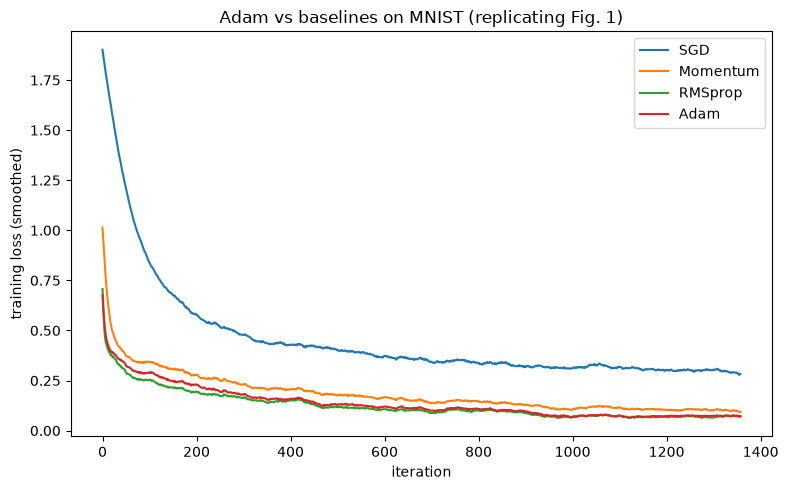

In [5]:
import numpy as np
def smooth(v, k=50): return np.convolve(v, np.ones(k)/k, mode="valid")
plt.figure(figsize=(8, 5))
for n, c in curves.items():
    plt.plot(smooth(c), label=n)
plt.xlabel("iteration"); plt.ylabel("training loss (smoothed)")
plt.title("Adam vs baselines on MNIST (replicating Fig. 1)")
plt.legend(); plt.tight_layout(); plt.show()